In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix

In [7]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)
Training labels: (50000, 1)
Testing labels: (10000, 1)


In [9]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

In [10]:
train_counts = np.bincount(y_train.flatten(), minlength=10)
test_counts = np.bincount(y_test.flatten(), minlength=10)

dataset_summary = pd.DataFrame({
    'Class': class_names,
    'Training Images': train_counts,
    'Testing Images': test_counts
})

dataset_summary

,Class,Training Images,Testing Images
0,airplane,5000,1000
1,automobile,5000,1000
2,bird,5000,1000
3,cat,5000,1000
4,deer,5000,1000
5,dog,5000,1000
6,frog,5000,1000
7,horse,5000,1000
8,ship,5000,1000
9,truck,5000,1000


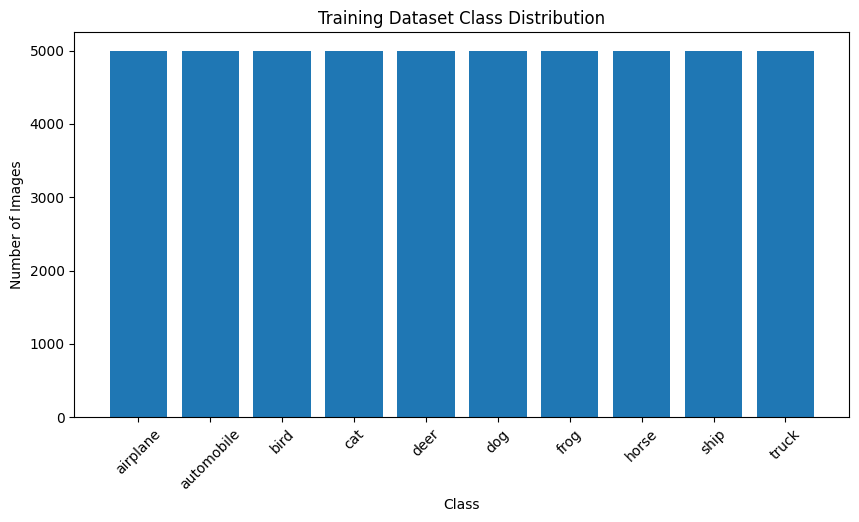

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(class_names, train_counts)
plt.title('Training Dataset Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

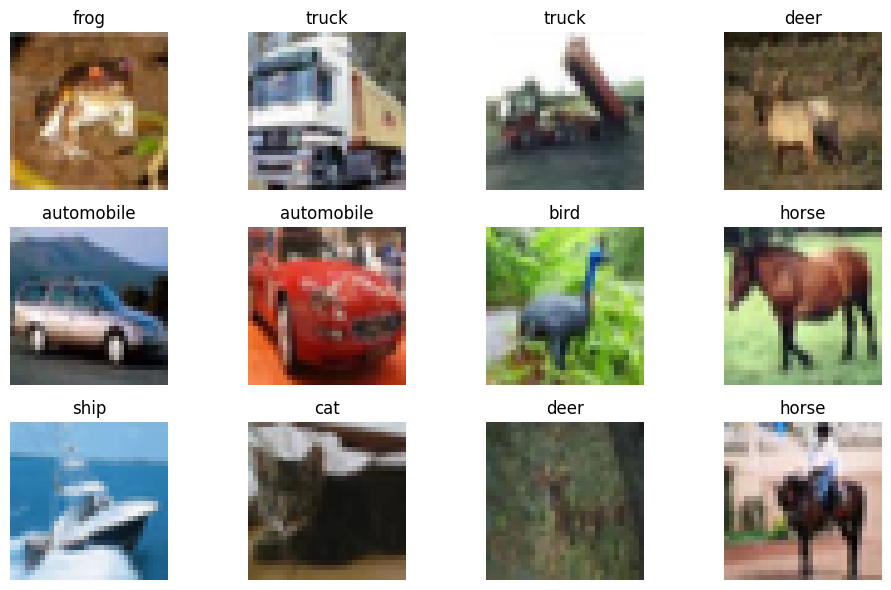

In [12]:
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [15]:
basic_model = models.Sequential([
    Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

basic_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
basic_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
basic_history = basic_model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4752 - loss: 1.4718 - val_accuracy: 0.5706 - val_loss: 1.2128
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6110 - loss: 1.1156 - val_accuracy: 0.6490 - val_loss: 1.0081
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6584 - loss: 0.9789 - val_accuracy: 0.6618 - val_loss: 0.9868
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6932 - loss: 0.8803 - val_accuracy: 0.6866 - val_loss: 0.9056
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7228 - loss: 0.8036 - val_accuracy: 0.6870 - val_loss: 0.9221
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7431 - loss: 0.7375 - val_accuracy: 0.7004 - val_loss: 0.8863
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7668 - loss: 0.6673 - val_accuracy: 0.7052 - val_loss: 0.8815
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7872 - loss: 0.6082 - val_accuracy: 0

In [18]:
basic_loss, basic_accuracy = basic_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Basic CNN Accuracy:", round(basic_accuracy * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6988 - loss: 1.1960
Basic CNN Accuracy: 69.88 %


In [19]:
model = models.Sequential([
    Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 358,218 (1.37 MB)

 Trainable params: 357,514 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [22]:
history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.4224 - loss: 1.7062 - val_accuracy: 0.5094 - val_loss: 1.3661 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5681 - loss: 1.2186 - val_accuracy: 0.6362 - val_loss: 1.0249 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6174 - loss: 1.0816 - val_accuracy: 0.6062 - val_loss: 1.1104 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6508 - loss: 0.9903 - val_accuracy: 0.6518 - val_loss: 1.0204 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6782 - loss: 0.9252 - val_accuracy: 0.6598 - val_loss: 1.0025 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6941 - loss: 0.8792 - val_accuracy: 0.6994 - val_loss: 0.8414 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7085 - loss: 0.8339 

In [23]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Enhanced CNN Accuracy:", round(test_accuracy * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8068 - loss: 0.5600
Enhanced CNN Accuracy: 80.68 %


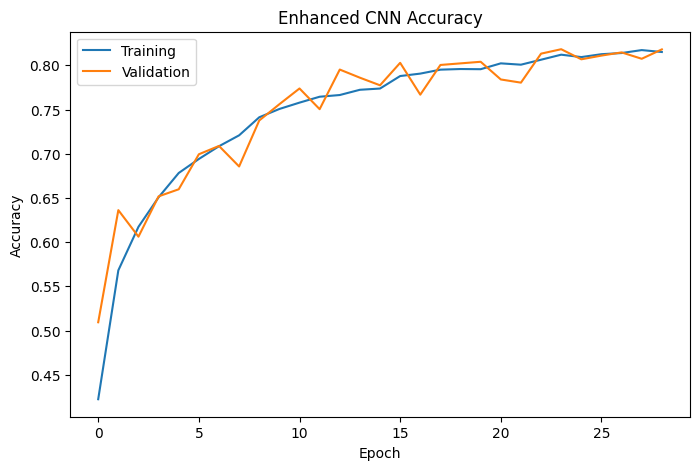

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Enhanced CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training', 'Validation'])
plt.show()

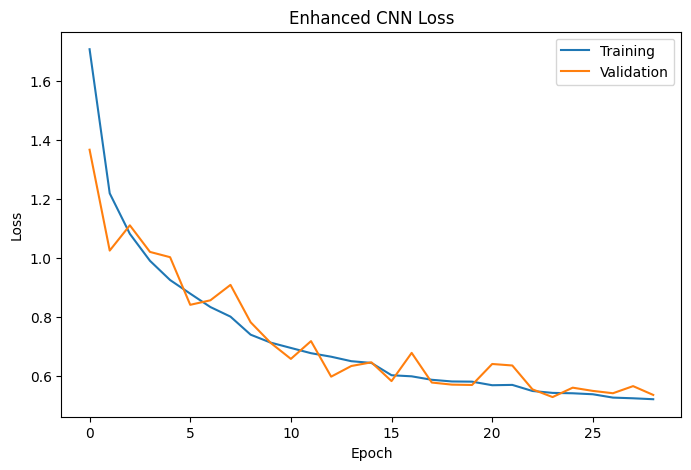

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Enhanced CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.show()

In [26]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

    airplane       0.82      0.85      0.83      1000
  automobile       0.91      0.90      0.91      1000
        bird       0.76      0.68      0.72      1000
         cat       0.64      0.63      0.63      1000
        deer       0.76      0.79      0.77      1000
         dog       0.71      0.71      0.71      1000
        frog       0.82      0.88      0.85      1000
       horse       0.87      0.85      0.86      1000
        ship       0.87      0.92      0.89      1000
       truck       0.90      0.86      0.88      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



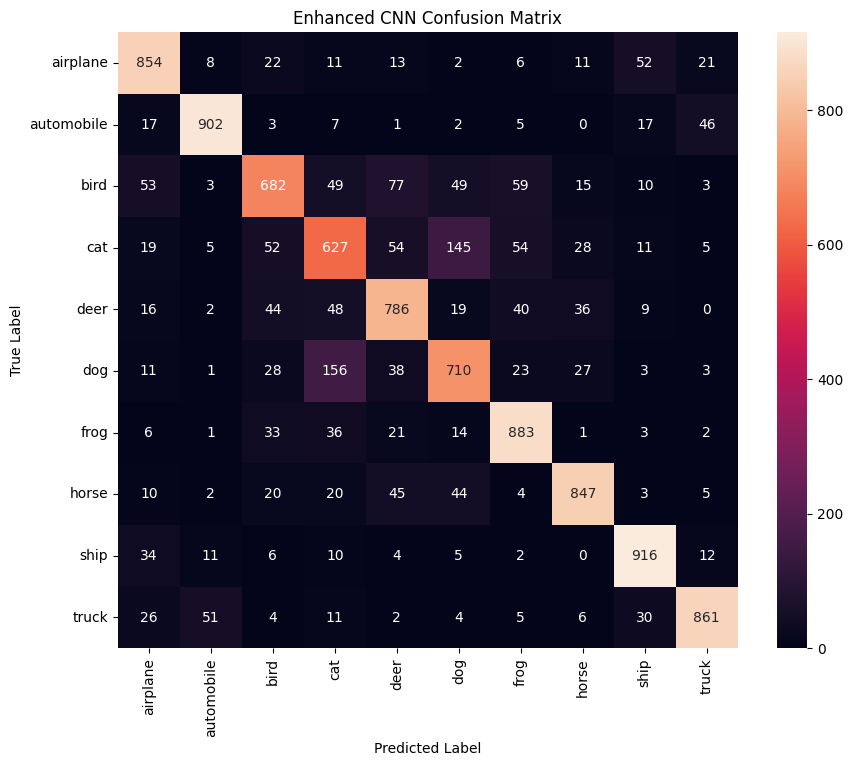

In [27]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Enhanced CNN Confusion Matrix')
plt.show()

In [28]:
print("Basic CNN Accuracy:", round(basic_accuracy * 100, 2), "%")
print("Enhanced CNN Accuracy:", round(test_accuracy * 100, 2), "%")
print("Improvement:", round((test_accuracy - basic_accuracy) * 100, 2), "%")

Basic CNN Accuracy: 69.88 %
Enhanced CNN Accuracy: 80.68 %
Improvement: 10.8 %


In [42]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False

transfer_model = models.Sequential([
    Input(shape=(32, 32, 3)), # Input matches original CIFAR-10 image size
    layers.Resizing(96, 96),  # Resizes images to 96x96
    layers.Rescaling(1./127.5, offset=-1), # Preprocesses for MobileNetV2
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

transfer_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [43]:
transfer_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [47]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
transfer_history = transfer_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 41ms/step - accuracy: 0.0978 - loss: 2.3081 - val_accuracy: 0.0958 - val_loss: 2.3027 - learning_rate: 0.0010
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.0972 - loss: 2.3027 - val_accuracy: 0.0976 - val_loss: 2.3028 - learning_rate: 0.0010
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.0983 - loss: 2.3027 - val_accuracy: 0.0976 - val_loss: 2.3029 - learning_rate: 5.0000e-04
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.0979 - loss: 2.3027 - val_accuracy: 0.0958 - val_loss: 2.3028 - learning_rate: 5.0000e-04
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.0987 - loss: 2.3026 - val_accuracy: 0.0950 - val_loss: 2.3028 - learning_rate: 2.5000e-04


In [49]:
transfer_loss, transfer_accuracy = transfer_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("MobileNetV2 Accuracy:", round(transfer_accuracy * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.1000 - loss: 2.3026
MobileNetV2 Accuracy: 10.0 %


In [50]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [51]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
fine_tune_history = transfer_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 40ms/step - accuracy: 0.2681 - loss: 2.0354 - val_accuracy: 0.0980 - val_loss: 2.3293 - learning_rate: 1.0000e-05
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3650 - loss: 1.7899 - val_accuracy: 0.0970 - val_loss: 2.6512 - learning_rate: 1.0000e-05
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.4010 - loss: 1.7006 - val_accuracy: 0.0970 - val_loss: 2.5917 - learning_rate: 5.0000e-06
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.4153 - loss: 1.6585 - val_accuracy: 0.0970 - val_loss: 2.8315 - learning_rate: 5.0000e-06
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.4281 - loss: 1.6240 - val_accuracy: 0.0972 - val_loss: 3.0391 - learning_rate: 2.5000e-06


In [53]:
fine_tune_loss, fine_tune_accuracy = transfer_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print(
    "Fine-Tuned MobileNetV2 Accuracy:",
    round(fine_tune_accuracy * 100, 2),
    "%"
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.0934 - loss: 2.3285
Fine-Tuned MobileNetV2 Accuracy: 9.34 %


In [54]:
results = {
    'Basic CNN': basic_accuracy,
    'Enhanced CNN': test_accuracy,
    'MobileNetV2': transfer_accuracy,
    'Fine-Tuned MobileNetV2': fine_tune_accuracy
}

for name, accuracy in results.items():
    print(name + ":", round(accuracy * 100, 2), "%")

Basic CNN: 69.88 %
Enhanced CNN: 80.68 %
MobileNetV2: 10.0 %
Fine-Tuned MobileNetV2: 9.34 %


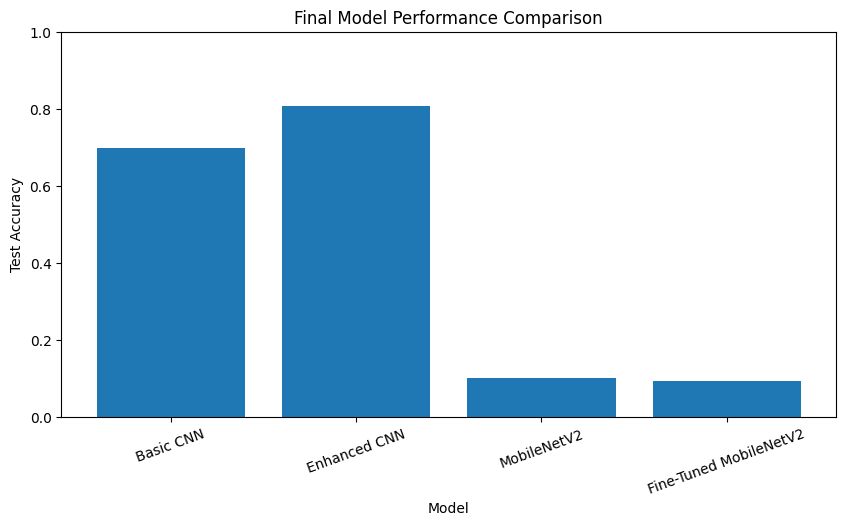

In [55]:
model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10, 5))
plt.bar(model_names, accuracies)
plt.title('Final Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [56]:
best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]

print("Best Model:", best_model_name)
print("Best Accuracy:", round(best_accuracy * 100, 2), "%")

Best Model: Enhanced CNN
Best Accuracy: 80.68 %


In [57]:
final_predictions = transfer_model.predict(x_test)
final_pred_classes = np.argmax(final_predictions, axis=1)
final_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step


In [58]:
print(classification_report(
    final_true,
    final_pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.00      0.00      0.00      1000
  automobile       0.00      0.00      0.00      1000
        bird       0.00      0.00      0.00      1000
         cat       0.00      0.00      0.00      1000
        deer       0.03      0.01      0.01      1000
         dog       0.09      0.89      0.17      1000
        frog       0.15      0.04      0.06      1000
       horse       0.00      0.00      0.00      1000
        ship       0.00      0.00      0.00      1000
       truck       0.00      0.00      0.00      1000

    accuracy                           0.09     10000
   macro avg       0.03      0.09      0.02     10000
weighted avg       0.03      0.09      0.02     10000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


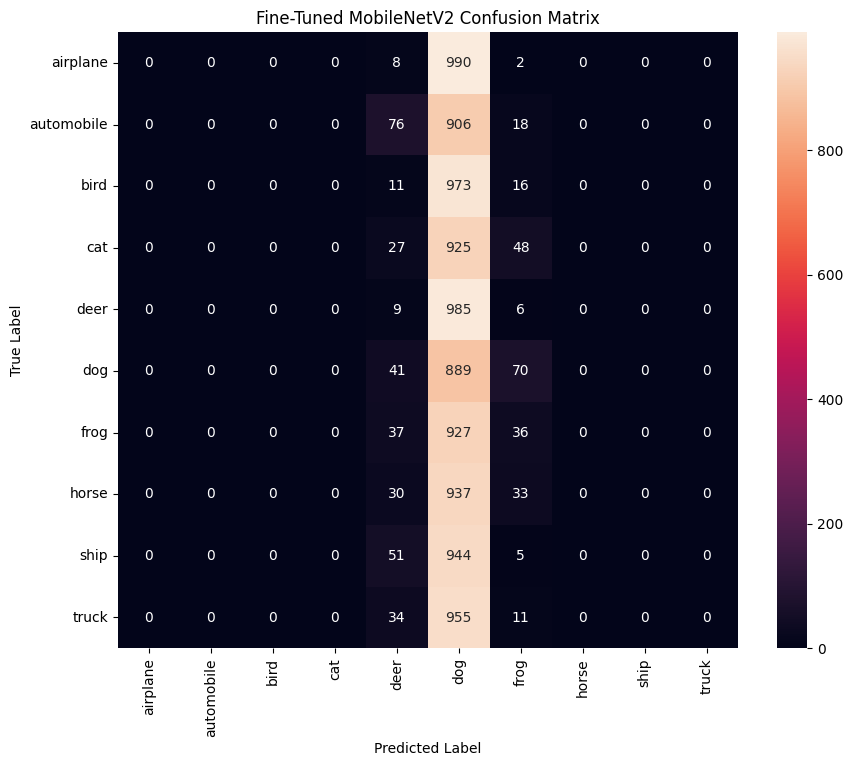

In [59]:
final_cm = confusion_matrix(
    final_true,
    final_pred_classes
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    final_cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Fine-Tuned MobileNetV2 Confusion Matrix')
plt.show()

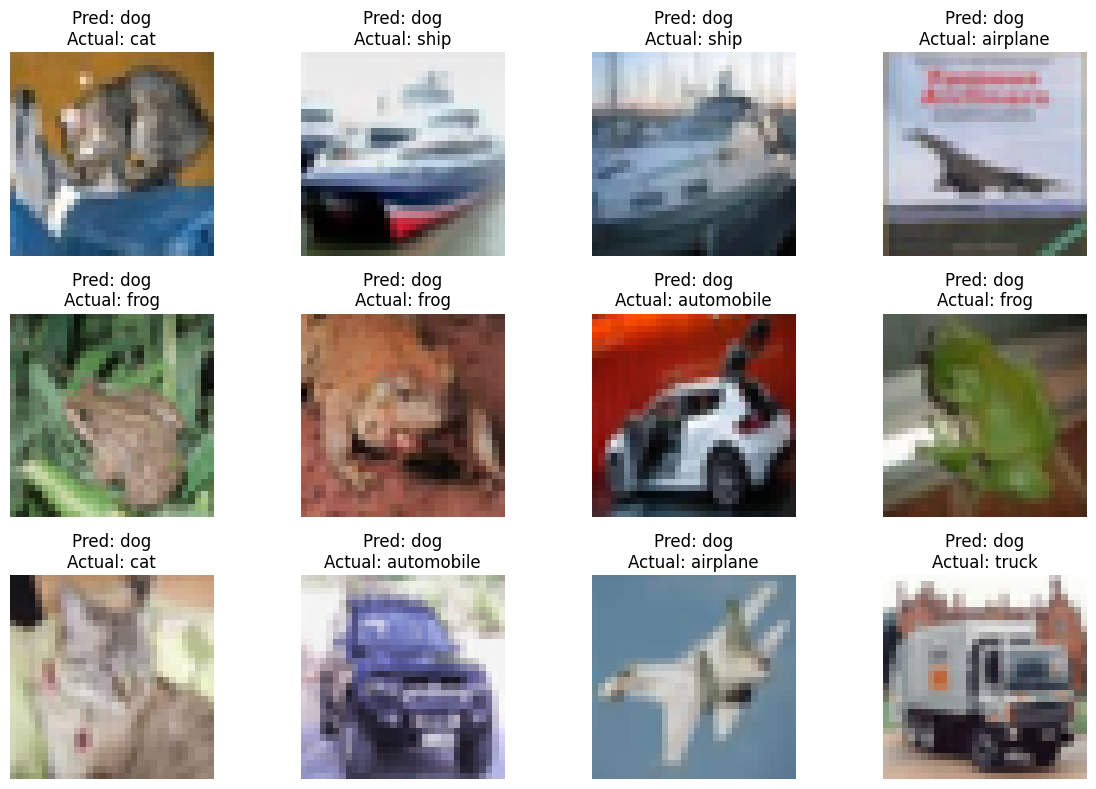

In [60]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i])

    predicted = class_names[final_pred_classes[i]]
    actual = class_names[final_true[i]]

    plt.title(f"Pred: {predicted}\nActual: {actual}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [61]:
transfer_model.save('CIFAR10_Image_Classifier.keras')
print("Model saved successfully.")

Model saved successfully.


In [65]:
from google.colab import files

uploaded = files.upload()

Saving banner.jpg to banner.jpg


In [66]:
from tensorflow.keras.utils import load_img, img_to_array

image_path = list(uploaded.keys())[0]

img = load_img(image_path, target_size=(96, 96))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = transfer_model.predict(img_array, verbose=0)[0]

predicted_class = np.argmax(prediction)
confidence = prediction[predicted_class] * 100

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", round(confidence, 2), "%")

Predicted Class: deer
Confidence: 12.64 %


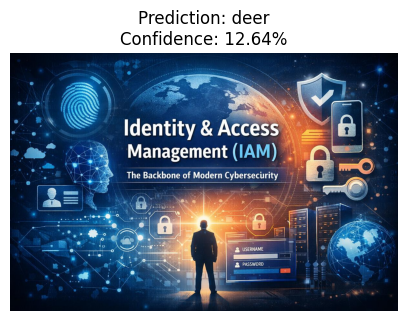

In [67]:
display_image = load_img(image_path)

plt.figure(figsize=(5, 5))
plt.imshow(display_image)
plt.title(
    f"Prediction: {class_names[predicted_class]}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis('off')
plt.show()

In [68]:
!pip install -q gradio

In [69]:
import gradio as gr

In [70]:
def predict_image(image):
    image = image.convert('RGB')
    image = image.resize((96, 96))

    image_array = np.array(image).astype('float32')
    image_array = np.expand_dims(image_array, axis=0)
    image_array = preprocess_input(image_array)

    prediction = transfer_model.predict(
        image_array,
        verbose=0
    )[0]

    return {
        class_names[i]: float(prediction[i])
        for i in range(10)
    }

In [71]:
demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="CIFAR-10 Image Classifier",
    description="Upload an image to classify it into one of the CIFAR-10 classes."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f2b78c9f9692adbee8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [72]:
print("===== FINAL PROJECT RESULTS =====")
print("Basic CNN:", round(basic_accuracy * 100, 2), "%")
print("Enhanced CNN:", round(test_accuracy * 100, 2), "%")
print("MobileNetV2:", round(transfer_accuracy * 100, 2), "%")
print("Fine-Tuned MobileNetV2:", round(fine_tune_accuracy * 100, 2), "%")
print("Best Model:", best_model_name)
print("Best Accuracy:", round(best_accuracy * 100, 2), "%")

===== FINAL PROJECT RESULTS =====
Basic CNN: 69.88 %
Enhanced CNN: 80.68 %
MobileNetV2: 10.0 %
Fine-Tuned MobileNetV2: 9.34 %
Best Model: Enhanced CNN
Best Accuracy: 80.68 %
